In [ ]:
from pathlib import Path
import numpy as np
from Utils.json_tools import read_formatted_json
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d
from plotting import plot_1d_rfmap


In [134]:
json_path = Path(
    "data/regular_260630_3_-100_200_A.json")

data = read_formatted_json(json_path)
assert data["unitsSpikeCountsSize"][3] == (len(data['timeBinEdges']) - 1) == len(data['unitsSpikeCounts'][0][0][0])
unitsSpikeCounts_time = np.asarray(data['unitsSpikeCounts'])
unitPool = np.asarray(data['unitPool'])

unitsSpikeCounts = unitsSpikeCounts_time.sum(axis=(1, 3))

data.keys()

dict_keys(['unitsSpikeCounts', 'unitsSpikeCountsSize', 'unitPool', 'xPositions', 'yPositions', 'VSTimeWindow', 'timeWindowMs', 'timeBinWidthMs', 'timeBinEdges'])

In [128]:
def normalized_shannon_entropy_per_row(arr):

    arr = np.asarray(arr, dtype=float)

    # row-wise sum: shape (n_rows, 1)

    row_sum = arr.sum(axis=1, keepdims=True)

    # avoid divide-by-zero for all-zero rows

    p = np.divide(arr, row_sum, out=np.zeros_like(arr), where=row_sum != 0)

    # entropy per row

    H = -np.sum(

        np.where(p > 0, p * np.log2(p), 0),

        axis=1

    )

    # max entropy per row = log2(number of columns)

    H_max = np.log2(arr.shape[1])

    return H / H_max

In [150]:
targetList = [
    108, 114, 124, 127, 131, 133, 134, 137, 139, 141, 153, 156, 160, 267, 270, 274, 275, 279, 280, 285, 287, 291, 294, 296, 307, 318, 423, 459,
]


selectedSpikeCounts = unitsSpikeCounts[np.isin(unitPool, targetList), :]

selectedUnitIDs = np.array(targetList)

unitsSpikeCounts_smooth = gaussian_filter1d(
    selectedSpikeCounts,
    sigma=1.5,
    axis=1
)

# rank_idx = np.argsort(maxIndex:= np.argmax(unitsSpikeCounts_smooth, axis=1))
rank_idx = np.asarray([ 2,  8, 15, 21, 24, 27, 10,  7, 25, 12,  3, 20, 16, 17,  4,  1, 26,
       19,  0, 22,  6,  5, 11, 13,  9, 23, 14, 18])
unitsSpikeCounts_smooth_sorted = unitsSpikeCounts_smooth[rank_idx, :]
targetList_sorted = selectedUnitIDs[rank_idx]

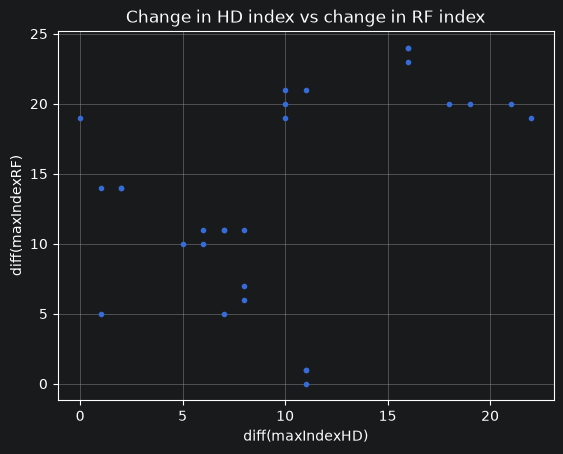

Pearson r = 0.4320, p = 0.02169


In [159]:
from scipy.stats import pearsonr

x = np.diff(maxIndexHD)
y = np.diff(maxIndexRF)

# dot / scatter plot
plt.figure()
plt.plot(x, y, '.', markersize=6)   # dot plot
# or: plt.scatter(x, y, s=20)

plt.xlabel('diff(maxIndexHD)')
plt.ylabel('diff(maxIndexRF)')
plt.title('Change in HD index vs change in RF index')
plt.grid(True)
plt.show()

# Pearson correlation
r, p = pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p = {p:.4g}")

In [158]:
import numpy as np
from scipy.stats import circmean

def circ_corrcc(alpha, beta):
    """
    Circular-circular correlation coefficient.
    alpha, beta: angles in radians
    """
    alpha = np.asarray(alpha)
    beta = np.asarray(beta)

    mask = ~np.isnan(alpha) & ~np.isnan(beta)
    alpha = alpha[mask]
    beta = beta[mask]

    alpha_bar = circmean(alpha, high=np.pi, low=-np.pi)
    beta_bar  = circmean(beta,  high=np.pi, low=-np.pi)

    sin_a = np.sin(alpha - alpha_bar)
    sin_b = np.sin(beta - beta_bar)

    denom = np.sqrt(np.sum(sin_a**2) * np.sum(sin_b**2))

    if denom == 0:
        return np.nan

    rho = np.sum(sin_a * sin_b) / denom
    return rho


def circ_corrcc_permtest(alpha, beta, n_perm=10000, seed=0):
    """
    Circular-circular correlation with permutation p-value.
    Two-sided p-value.
    """
    rng = np.random.default_rng(seed)

    alpha = np.asarray(alpha)
    beta = np.asarray(beta)

    mask = ~np.isnan(alpha) & ~np.isnan(beta)
    alpha = alpha[mask]
    beta = beta[mask]

    rho_obs = circ_corrcc(alpha, beta)

    perm_rhos = np.empty(n_perm)

    for i in range(n_perm):
        beta_perm = rng.permutation(beta)
        perm_rhos[i] = circ_corrcc(alpha, beta_perm)

    # two-sided permutation p-value
    p_value = (np.sum(np.abs(perm_rhos) >= np.abs(rho_obs)) + 1) / (n_perm + 1)

    return rho_obs, p_value


nBinsHD = 24
nBinsRF = 30

alpha = np.asarray(maxIndexHD) / nBinsHD * 2*np.pi
beta  = np.asarray(maxIndexRF) / nBinsRF * 2*np.pi

rho_circ, p_circ = circ_corrcc_permtest(alpha, beta, n_perm=10000, seed=1)

print(f"Circular correlation = {rho_circ:.4f}")
print(f"Permutation p-value = {p_circ:.4g}")

Circular correlation = 0.5573
Permutation p-value = 0.0028


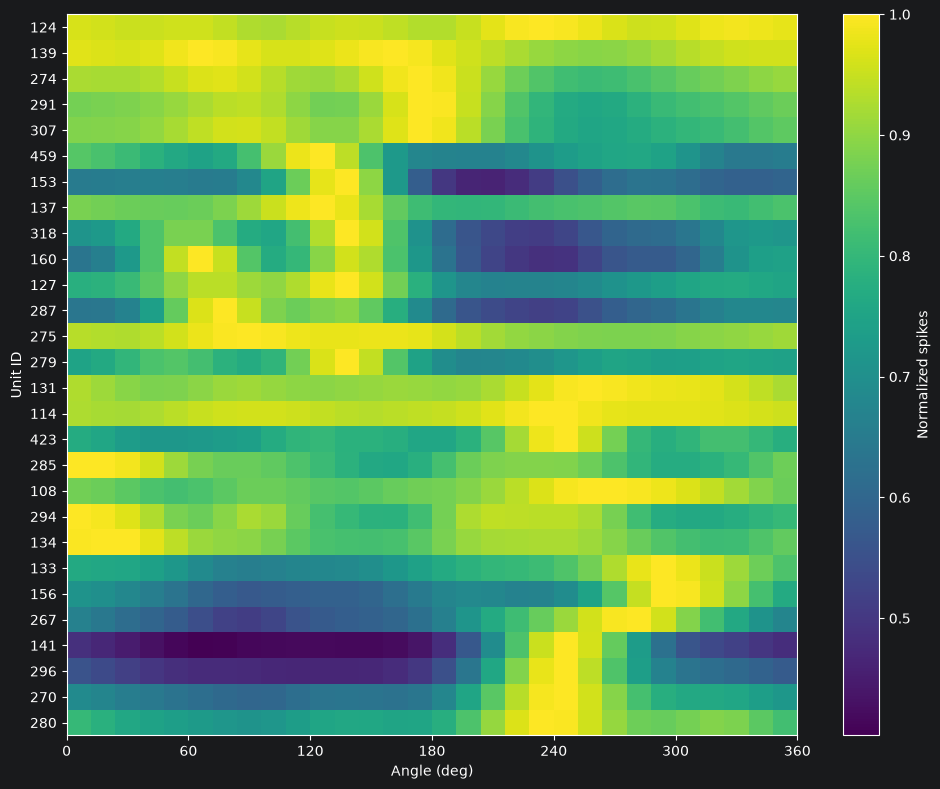

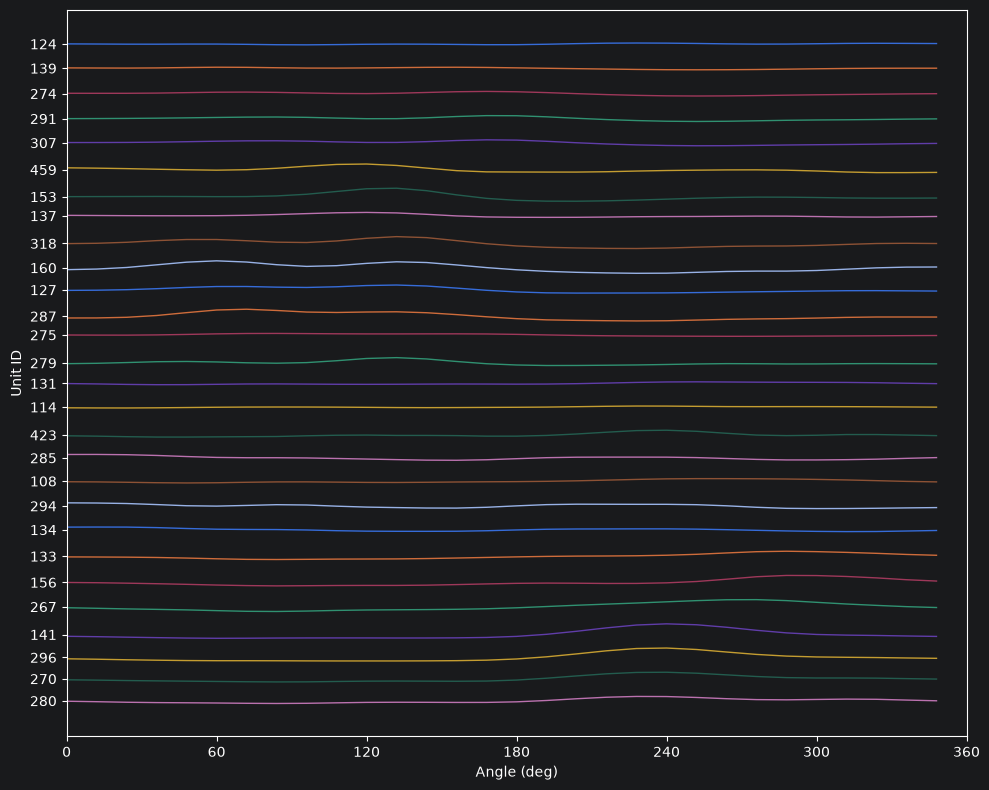

In [157]:
plot_1d_rfmap(
    unitsSpikeCounts_smooth_sorted,
    targetList_sorted,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)

plot_1d_rfmap(
    unitsSpikeCounts_smooth_sorted,
    targetList_sorted,
    isLineplot=True,
    xinDeg=True,
    isNormalize=True,
)

In [ ]:
unitsSpikeCounts_smooth_sorted

In [ ]:
x_idx = 2
values = unit_x[:, x_idx]  # one value per unit

unit_ids = np.arange(unit_x.shape[0])

img = values.reshape(1, -1)

plt.figure(figsize=(12, 1.5))
plt.imshow(img, aspect="equal", cmap="viridis")

plt.xticks(np.arange(len(unit_ids)), unit_ids)
plt.yticks([])

plt.xlabel("Unit ID")
plt.title(f"x = {x_idx}")
plt.colorbar(label="Summed value")

plt.tight_layout()
plt.show()

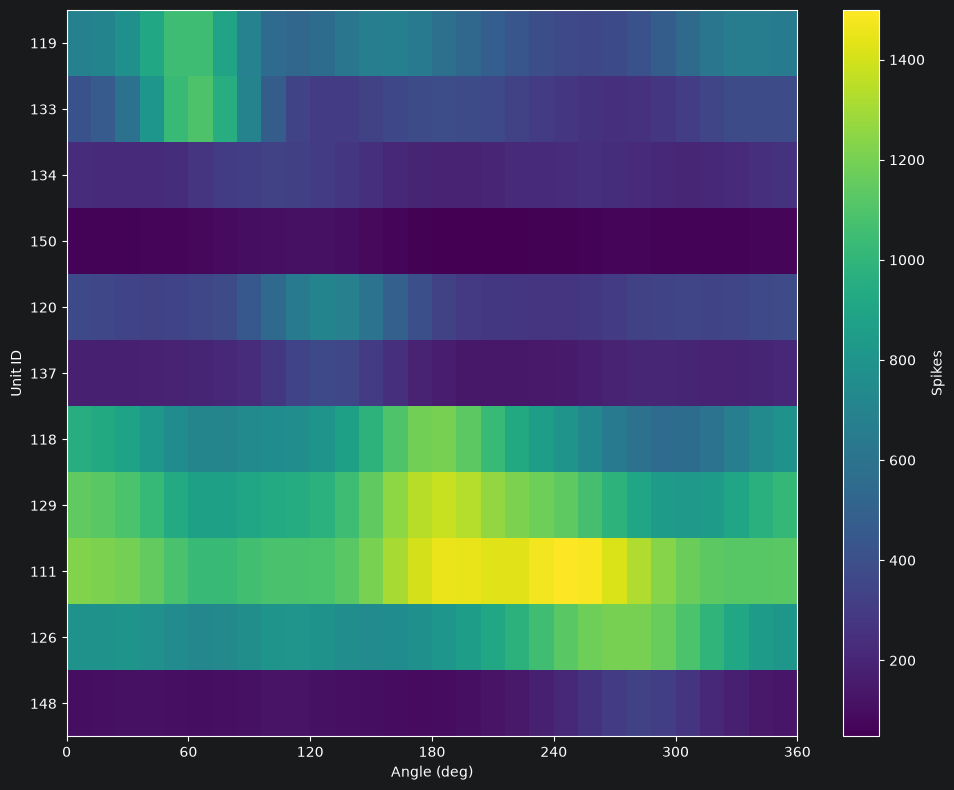

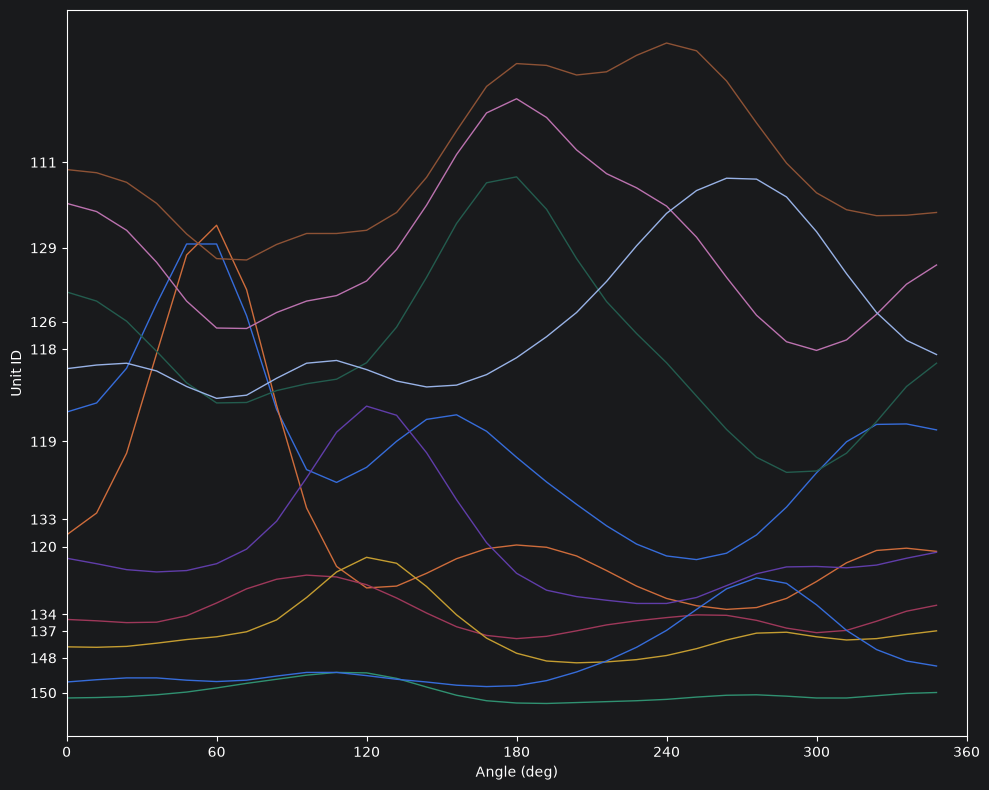